<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/QML_Predictive_Maintenance_MES_PLC_Qiskit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Maintenance with Quantum ML (Qiskit)
## MES + Sensor/PLC Layer → Failure Prediction Pipeline

**Hedef kitle:** QML / Quantum Computing ogrencileri  
**Senaryo:** Fabrika hattinda motor / pompa / kompresor icin ariza tahmini  

**Mimari katmanlar:**
1. **Sensor / PLC** – titresim, sicaklik, akim, basinc (IoT / OPC-UA simulasyonu)
2. **MES** – is emri, makine durumu, uretim sayaci, alarm gecmisi
3. **Feature Store** – pencereme, istatistikler, etiketleme
4. **Quantum ML** – Quantum Kernel + QSVC
5. **Karar katmani** – bakim onerisi, OEE etkisi

> Egitim amacli toy dataset. Gercek uretimde edge gateway + historian + hybrid pipeline gerekir.


## 0. Ortam Kurulumu

In [ ]:
# Colab kurulumu
%pip install -q "qiskit>=1.0" qiskit-machine-learning qiskit-aer \
               matplotlib seaborn pandas numpy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

try:
    from IPython.display import display
except ImportError:
    display = print

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
sns.set_palette("colorblind")
print("Kurulum tamam:", datetime.now().strftime("%Y-%m-%d %H:%M"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00
Kurulum tamam: 2026-08-11 09:46


## 1. Endustriyel Mimari

```
[PLC / Sensorler]          [MES / SCADA]
  titresim (mm/s)            is emri no
  sicaklik (C)               makine durumu (RUN/IDLE/DOWN)
  motor akimi (A)            uretim sayaci
  basinc (bar)               alarm kodlari
        \                      /
         v                    v
     Edge / Gateway  (OPC-UA, MQTT, historian)
              |
              v
     Feature engineering
              |
              v
     Quantum ML (Qiskit QSVC)
              |
              v
     Bakim karari + OEE etkisi
```


## 2. Sensor / PLC Katmani Simulasyonu

PLC analog/digital sinyalleri:
- titresim, sicaklik, akim, basinc, rpm
- motor_run, emergency_stop

Etiket: `failure_soon = 1` → sonraki 24 saat icinde ariza riski yuksek.


In [ ]:
np.random.seed(42)

MACHINES = ["MTR-01", "PMP-02", "CMP-03"]
N_SAMPLES = 240

def simulate_plc_sensors(n=N_SAMPLES, failure_ratio=0.28):
    rows = []
    for i in range(n):
        machine = np.random.choice(MACHINES)
        vibration = np.random.normal(2.5, 0.6)
        temperature = np.random.normal(55, 5)
        current = np.random.normal(12, 1.5)
        pressure = np.random.normal(6.0, 0.4)
        rpm = np.random.normal(1450, 30)
        motor_run = 1
        emergency_stop = 0

        is_fail = 1 if np.random.rand() < failure_ratio else 0
        if is_fail:
            vibration += np.random.uniform(3.0, 6.0)
            temperature += np.random.uniform(15, 30)
            current += np.random.uniform(4, 8)
            pressure += np.random.uniform(-1.5, 1.0)
            rpm -= np.random.uniform(50, 150)

        vibration = max(0.1, vibration + np.random.normal(0, 0.15))
        temperature = temperature + np.random.normal(0, 1.0)

        rows.append({
            "ts": datetime(2026, 3, 1) + timedelta(hours=i),
            "machine_id": machine,
            "vibration_mms": round(vibration, 3),
            "temp_c": round(temperature, 2),
            "current_a": round(current, 2),
            "pressure_bar": round(pressure, 2),
            "rpm": round(rpm, 1),
            "motor_run": motor_run,
            "emergency_stop": emergency_stop,
            "failure_soon": is_fail,
        })
    return pd.DataFrame(rows)

plc_df = simulate_plc_sensors()
print("PLC / Sensor katmani ornekleri:")
display(plc_df.head(8))
print("\nSinif dagilimi (failure_soon):")
print(plc_df["failure_soon"].value_counts())
print(f"\nToplam kayit: {len(plc_df)}")


PLC / Sensor katmani ornekleri:


,ts,machine_id,vibration_mms,temp_c,current_a,pressure_bar,rpm,motor_run,emergency_stop,failure_soon
0,2026-03-01 00:00:00,CMP-03,2.151,56.69,12.71,6.55,1422.5,1,0,0
1,2026-03-01 01:00:00,CMP-03,1.861,53.60,12.81,5.81,1436.0,1,0,0
2,2026-03-01 02:00:00,MTR-01,1.260,59.15,11.62,5.93,1405.7,1,0,0
3,2026-03-01 03:00:00,CMP-03,2.435,50.94,13.42,6.12,1430.9,1,0,0
4,2026-03-01 04:00:00,CMP-03,2.215,47.03,12.85,5.72,1408.7,1,0,0
5,2026-03-01 05:00:00,PMP-02,1.945,51.12,13.78,6.31,1529.7,1,0,0
6,2026-03-01 06:00:00,CMP-03,8.127,87.90,17.31,3.81,1328.2,1,0,1
7,2026-03-01 07:00:00,MTR-01,2.924,58.38,12.26,6.26,1457.2,1,0,0



Sinif dagilimi (failure_soon):
failure_soon
0    177
1     63
Name: count, dtype: int64

Toplam kayit: 240


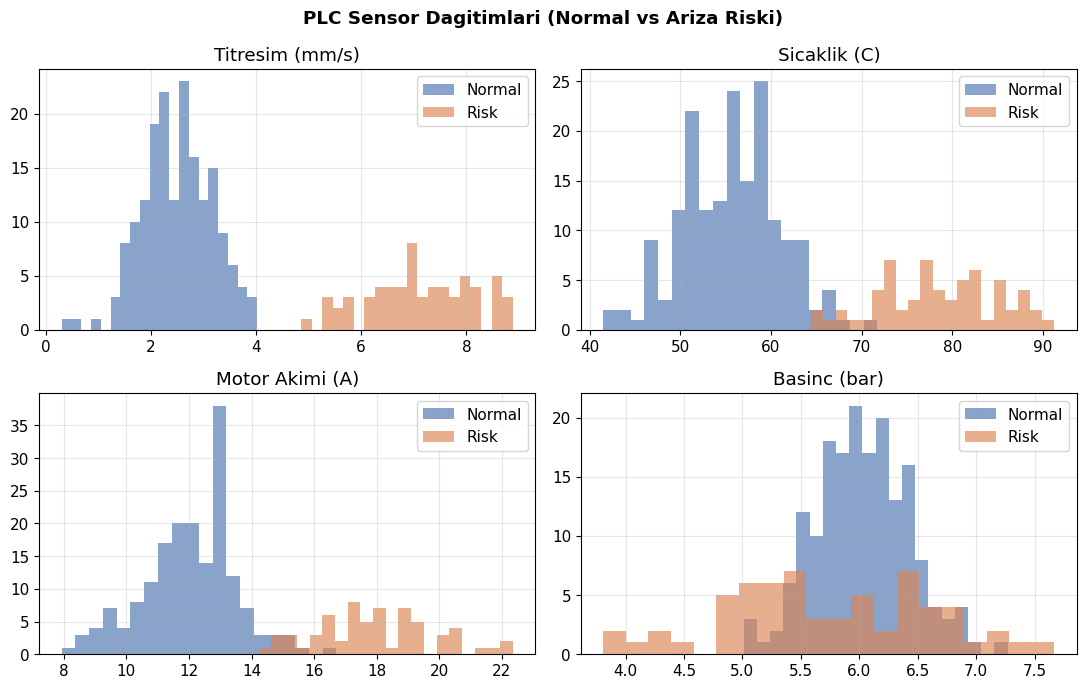

In [ ]:
# Sensor dagilimlari
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("PLC Sensor Dagitimlari (Normal vs Ariza Riski)", fontweight="bold")

for ax, (col, title) in zip(axes.ravel(), [
    ("vibration_mms", "Titresim (mm/s)"),
    ("temp_c", "Sicaklik (C)"),
    ("current_a", "Motor Akimi (A)"),
    ("pressure_bar", "Basinc (bar)"),
]):
    for label, color, name in [(0, "#4C72B0", "Normal"), (1, "#DD8452", "Risk")]:
        subset = plc_df[plc_df["failure_soon"] == label][col]
        ax.hist(subset, bins=20, alpha=0.65, color=color, label=name)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()


## 3. MES Katmani Simulasyonu

MES baglami: is emri, makine durumu, OEE, son bakim, alarm sayisi.


In [ ]:
def simulate_mes_context(plc_df):
    mes_rows = []
    for _, row in plc_df.iterrows():
        machine = row["machine_id"]
        wo = f"WO-{machine[-2:]}-{np.random.randint(1000, 9999)}"
        if row["failure_soon"] == 1 and np.random.rand() < 0.35:
            status = np.random.choice(["DOWN", "MAINT"], p=[0.6, 0.4])
        else:
            status = np.random.choice(["RUN", "IDLE"], p=[0.85, 0.15])
        availability = np.random.uniform(0.75, 0.98) if status == "RUN" else np.random.uniform(0.4, 0.7)
        performance = np.random.uniform(0.80, 0.99)
        quality = np.random.uniform(0.92, 0.995)
        oee = availability * performance * quality
        days_since_maint = np.random.randint(1, 90)
        alarm_count_24h = int(np.random.poisson(3 if row["failure_soon"] else 0.4))
        mes_rows.append({
            "work_order": wo,
            "mes_status": status,
            "oee": round(oee, 3),
            "availability": round(availability, 3),
            "days_since_maint": days_since_maint,
            "alarm_count_24h": alarm_count_24h,
        })
    mes_df = pd.DataFrame(mes_rows)
    return pd.concat([plc_df.reset_index(drop=True), mes_df], axis=1)

factory_df = simulate_mes_context(plc_df)
print("MES + PLC birlesik tablo:")
display(factory_df.head(6))
print("\nMES status dagilimi:")
print(factory_df["mes_status"].value_counts())


MES + PLC birlesik tablo:


,ts,machine_id,vibration_mms,temp_c,current_a,pressure_bar,rpm,motor_run,emergency_stop,failure_soon,work_order,mes_status,oee,availability,days_since_maint,alarm_count_24h
0,2026-03-01 00:00:00,CMP-03,2.151,56.69,12.71,6.55,1422.5,1,0,0,WO-03-2932,RUN,0.810,0.879,33,0
1,2026-03-01 01:00:00,CMP-03,1.861,53.60,12.81,5.81,1436.0,1,0,0,WO-03-7474,RUN,0.794,0.946,16,0
2,2026-03-01 02:00:00,MTR-01,1.260,59.15,11.62,5.93,1405.7,1,0,0,WO-01-3743,RUN,0.832,0.976,89,1
3,2026-03-01 03:00:00,CMP-03,2.435,50.94,13.42,6.12,1430.9,1,0,0,WO-03-1619,RUN,0.931,0.959,80,2
4,2026-03-01 04:00:00,CMP-03,2.215,47.03,12.85,5.72,1408.7,1,0,0,WO-03-9199,RUN,0.662,0.821,81,0
5,2026-03-01 05:00:00,PMP-02,1.945,51.12,13.78,6.31,1529.7,1,0,0,WO-02-6973,IDLE,0.545,0.581,28,0



MES status dagilimi:
mes_status
RUN      194
IDLE      29
MAINT      9
DOWN       8
Name: count, dtype: int64


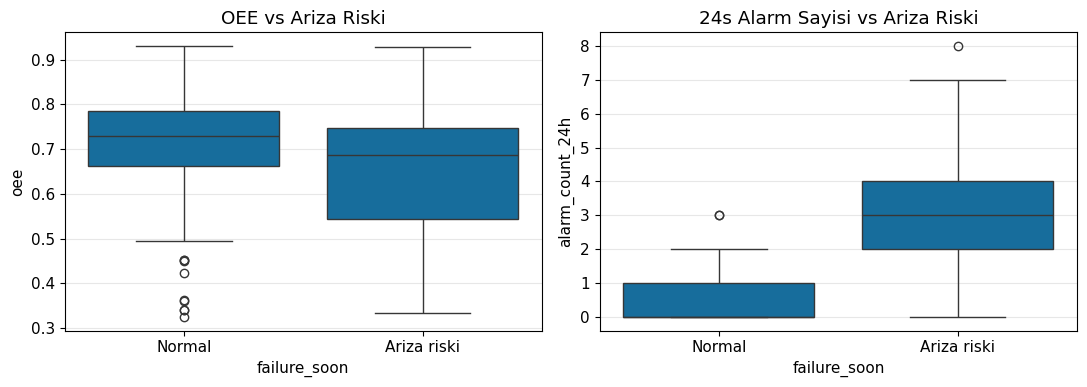

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=factory_df, x="failure_soon", y="oee", ax=axes[0])
axes[0].set_xticklabels(["Normal", "Ariza riski"])
axes[0].set_title("OEE vs Ariza Riski")
sns.boxplot(data=factory_df, x="failure_soon", y="alarm_count_24h", ax=axes[1])
axes[1].set_xticklabels(["Normal", "Ariza riski"])
axes[1].set_title("24s Alarm Sayisi vs Ariza Riski")
plt.tight_layout()
plt.show()


## 4. Feature Engineering

Model girdisi (6 feature – quantum encoding icin uygun):
1. vibration_mms
2. temp_c
3. current_a
4. pressure_bar
5. days_since_maint
6. alarm_count_24h


In [ ]:
FEATURE_COLS = [
    "vibration_mms", "temp_c", "current_a",
    "pressure_bar", "days_since_maint", "alarm_count_24h",
]
TARGET = "failure_soon"

X = factory_df[FEATURE_COLS].values.astype(float)
y = factory_df[TARGET].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_q = scaler.fit_transform(X_train)
X_test_q = scaler.transform(X_test)

scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train)
X_test_c = scaler_c.transform(X_test)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Feature boyutu: {X_train.shape[1]}")
print(f"Pozitif sinif orani (train): {y_train.mean():.2%}")


Train: 168 | Test: 72
Feature boyutu: 6
Pozitif sinif orani (train): 26.19%


## 5. Klasik Baseline

=== Klasik Baseline ===
Random Forest accuracy: 1.000
RBF-SVM accuracy      : 1.000

Random Forest report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        53
           1      1.000     1.000     1.000        19

    accuracy                          1.000        72
   macro avg      1.000     1.000     1.000        72
weighted avg      1.000     1.000     1.000        72



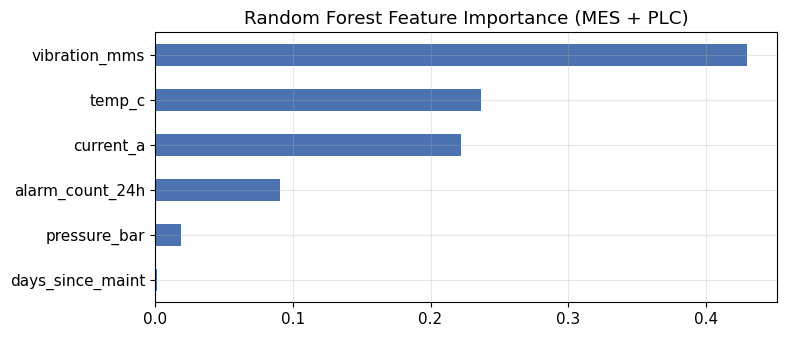

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train_c, y_train)
y_rf = rf.predict(X_test_c)
acc_rf = accuracy_score(y_test, y_rf)

svc_c = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
svc_c.fit(X_train_c, y_train)
y_svc = svc_c.predict(X_test_c)
acc_svc = accuracy_score(y_test, y_svc)

print("=== Klasik Baseline ===")
print(f"Random Forest accuracy: {acc_rf:.3f}")
print(f"RBF-SVM accuracy      : {acc_svc:.3f}")
print("\nRandom Forest report:")
print(classification_report(y_test, y_rf, digits=3))

imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 3.5))
imp.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Random Forest Feature Importance (MES + PLC)")
plt.tight_layout()
plt.show()


## 6. Quantum Kernel + QSVC (Qiskit)

ZZFeatureMap ile encoding, FidelityQuantumKernel, QSVC.

Colab hizi icin reps=1, linear entanglement, sinirli ornek sayisi.


In [ ]:
MAX_TRAIN = 50
MAX_TEST = 25
Xtr = X_train_q[:MAX_TRAIN]
ytr = y_train[:MAX_TRAIN]
Xte = X_test_q[:MAX_TEST]
yte = y_test[:MAX_TEST]

print(f"Quantum train: {len(Xtr)} | test: {len(Xte)}", flush=True)

feature_map = ZZFeatureMap(
    feature_dimension=len(FEATURE_COLS),
    reps=1,
    entanglement="linear",
)

print("Feature map devresi...", flush=True)
try:
    feature_map.decompose().draw(output="mpl", style="iqp", fold=50)
    plt.suptitle("ZZFeatureMap – Predictive Maintenance Encoding", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("MPL drawer atlandi:", type(e).__name__)
    print(feature_map.decompose().draw(output="text", fold=60))

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

print("QSVC egitiliyor (genelde 1-2 dk)...", flush=True)
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(Xtr, ytr)
y_q = qsvc.predict(Xte)
acc_q = accuracy_score(yte, y_q)

print("=" * 50)
print(f"QSVC accuracy: {acc_q:.3f}")
print(classification_report(yte, y_q, digits=3))


Quantum train: 50 | test: 25
Feature map devresi...
MPL drawer atlandi: MissingOptionalLibraryError
     ┌───┐┌───────────┐                                   »
q_0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├»
     ├───┤├───────────┤└───┘└────────────────────────────┘»
q_2: ┤ H ├┤ P(2*x[2]) ├───────────────────────────────────»
     ├───┤├───────────┤                                   »
q_3: ┤ H ├┤ P(2*x[3]) ├───────────────────────────────────»
     ├───┤├───────────┤                                   »
q_4: ┤ H ├┤ P(2*x[4]) ├───────────────────────────────────»
     ├───┤├───────────┤                                   »
q_5: ┤ H ├┤ P(2*x[5]) ├───────────────────────────────────»
     └───┘└───────────┘                                   »
«                                                       »
«q_0: ──■───────────────────────────────────────────────»
«   

Kernel matrisi hesaplaniyor...


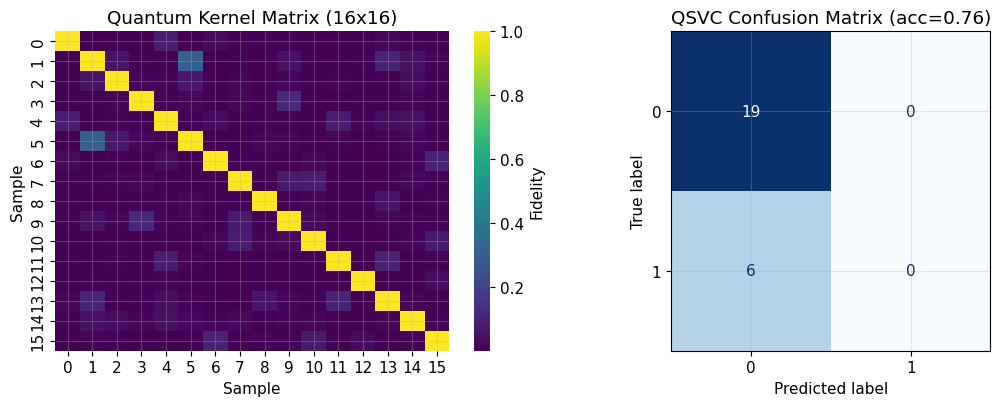

In [ ]:
print("Kernel matrisi hesaplaniyor...", flush=True)
K = quantum_kernel.evaluate(x_vec=Xtr[:16])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.heatmap(K, ax=axes[0], cmap="viridis", cbar_kws={"label": "Fidelity"})
axes[0].set_title("Quantum Kernel Matrix (16x16)")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Sample")

ConfusionMatrixDisplay.from_predictions(yte, y_q, ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"QSVC Confusion Matrix (acc={acc_q:.2f})")
plt.tight_layout()
plt.show()


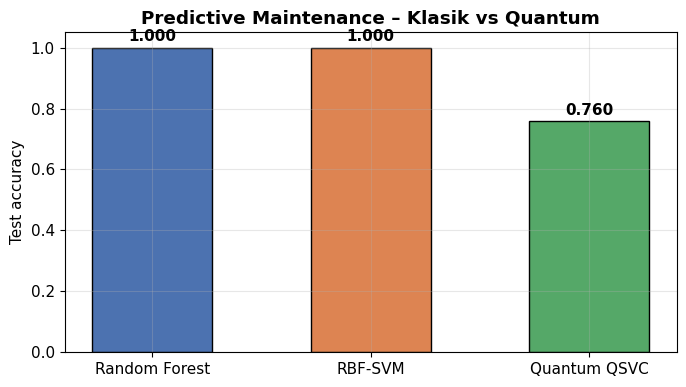

In [ ]:
Xte_c = X_test_c[:MAX_TEST]
yte_c = y_test[:MAX_TEST]
acc_rf_s = accuracy_score(yte_c, rf.predict(Xte_c))
acc_svc_s = accuracy_score(yte_c, svc_c.predict(Xte_c))

labels = ["Random Forest", "RBF-SVM", "Quantum QSVC"]
scores = [acc_rf_s, acc_svc_s, acc_q]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, scores, color=colors, edgecolor="k", width=0.55)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test accuracy")
ax.set_title("Predictive Maintenance – Klasik vs Quantum", fontweight="bold")
for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width() / 2, s + 0.02, f"{s:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Karar Katmani – Bakim Onerisi

| Risk | Aksiyon |
|------|---------|
| Dusuk | Normal operasyon |
| Orta | Planli bakim penceresi |
| Yuksek | Acil inceleme |


In [ ]:
def maintenance_decision(sample_features):
    x_q = scaler.transform(sample_features.reshape(1, -1))
    x_c = scaler_c.transform(sample_features.reshape(1, -1))
    pred = int(qsvc.predict(x_q)[0])
    try:
        proba = float(rf.predict_proba(x_c)[0, 1])
    except Exception:
        proba = float(pred)

    if proba >= 0.65 or pred == 1:
        action = "YUKSEK RISK -> Acil inceleme / planli durus"
        level = "HIGH"
    elif proba >= 0.40:
        action = "ORTA RISK -> 48s icinde bakim penceresi"
        level = "MEDIUM"
    else:
        action = "DUSUK RISK -> Normal operasyon"
        level = "LOW"
    return {"pred": pred, "proba_rf": proba, "level": level, "action": action}

print("Canli karar ornekleri (son kayitlar):\n")
for idx in factory_df.tail(5).index:
    row = factory_df.loc[idx]
    feats = row[FEATURE_COLS].values.astype(float)
    dec = maintenance_decision(feats)
    print(
        f"{row['machine_id']} | vib={row['vibration_mms']:.1f} temp={row['temp_c']:.0f} "
        f"| true={row['failure_soon']} pred={dec['pred']} | {dec['level']}: {dec['action']}"
    )


Canli karar ornekleri (son kayitlar):

CMP-03 | vib=2.6 temp=57 | true=0 pred=0 | LOW: DUSUK RISK -> Normal operasyon
CMP-03 | vib=2.4 temp=54 | true=0 pred=0 | LOW: DUSUK RISK -> Normal operasyon
PMP-02 | vib=3.7 temp=50 | true=0 pred=0 | LOW: DUSUK RISK -> Normal operasyon
CMP-03 | vib=2.6 temp=56 | true=0 pred=0 | LOW: DUSUK RISK -> Normal operasyon
PMP-02 | vib=7.4 temp=73 | true=1 pred=1 | HIGH: YUKSEK RISK -> Acil inceleme / planli durus


## 8. Uretim Entegrasyon Semasi

```
PLC (S7 / ControlLogix) --OPC-UA/MQTT--> Edge Gateway
                                              |
MES (SAP ME / Opcenter) ----------------------+
                                              v
                                    Feature service
                                              |
                         +--------------------+--------------------+
                         v                                         v
                Classical models (RF)                     Quantum kernel (Qiskit)
                         |                                         |
                         +--------------------+--------------------+
                                              v
                                    Risk score + work order
                                              v
                                    CMMS / bakim planlama
```


## 9. Ogrenci Alistirmalari

1. `failure_ratio` degerini degistirip sinif dengesinin QSVC performansina etkisini olcun.
2. Feature setine `rpm` ve `oee` ekleyip accuracy degisimini kaydedin.
3. `ZZFeatureMap` yerine `PauliFeatureMap` deneyin.
4. `reps=2` yapip devre derinligi vs dogruluk trade-off unu tartisin.
5. Sadece bir makine (`MTR-01`) icin model egitin.
6. (Ileri) IBM Quantum Runtime ile ayni QSVC yi gercek backend de calistirin.
7. False Negative maliyeti yuksekse threshold u dusurun; precision-recall tartisin.


## 10. Ozet

Bu notebook ta ogrenciler:
- **PLC/sensor** telemetrisini simule etti
- **MES** uretim baglamini ekledi
- Klasik baseline (RF, SVM) kurdu
- **Qiskit Quantum Kernel + QSVC** ile ariza tahmini yapti
- Operasyonel bakim kararina map ledi

### Kaynaklar
- Qiskit Machine Learning – Quantum Kernel / QSVC
- ISO 13374 (Condition monitoring)
- ISA-95 / MES katman modeli

---
**QML dersi – Predictive Maintenance (MES + PLC + Qiskit)**
